# 1. Business Context

This notebook develops an ML-based customer propensity model for term-deposit subscription in a bank marketing context. The goal is to estimate the probability that a customer will subscribe given customer, campaign, and economic context information. This is a decision-support model and not a guarantee of future customer behavior.

The final production model will prioritize customers for marketing outreach based on propensity score, while leaving the actual contact decision to business judgment, capacity planning, compliance, and customer experience considerations.


# 2. Dataset Description

We use the Bank Marketing dataset from the UCI repository, specifically the bank-additional-full.csv file. This dataset contains customer profile information, campaign contact history, and macroeconomic context variables. The target variable is `y`, which indicates whether a customer subscribed to a term deposit (`yes` or `no`).

This notebook explicitly compares two scenarios:
- a benchmark model with `duration` included
- a production-style model with `duration` excluded to avoid leakage from information available only after the current contact is already underway


# 3. Imports and Configuration

We keep the workflow reproducible and self-contained in this notebook. The same random state is used throughout the experiment to make results consistent and comparable.


# 4. Data Loading

The dataset is loaded from the existing repository path and inspected before modeling. We convert the target to numeric form for model training while keeping the business interpretation of `yes`/`no` in mind.


# 5. Data Validation

We validate the schema and basic target balance before building any model. We also inspect the actual values for categorical fields, because the dataset includes literal `unknown` categories that should not be silently dropped.


# 6. Exploratory Data Analysis

This section reviews the class imbalance, feature distributions, category-level response rates, and correlations. The goal is to understand the patterns in the data before finalizing the modeling strategy.


# 7. Data Quality & Cleaning

The dataset has no missing values in the raw file, but we still preserve a robust preprocessing pipeline. One additional feature, `previously_contacted`, is derived from `pdays != 999` because it reflects whether a customer had previous campaign contact history.


# 8. Leakage Analysis

The `duration` feature is the central leakage concern. It is known only after or during the call, so it is not appropriate for a pre-contact propensity model. We compare benchmark and production scenarios to quantify the effect.


# 9. Feature Engineering

Feature engineering remains limited to meaningful derived variables. The `previously_contacted` indicator is useful because it captures prior campaign activity without using post-contact information.


# 10. Train-Test Split

We use an 80/20 split with stratification because the target is imbalanced. This creates a final held-out test set that is not used for tuning.


# 11. Preprocessing Pipeline

Numerical features are imputed and scaled; categorical features are imputed and one-hot encoded. The same logic is applied separately inside each training fold through the pipeline to prevent leakage.


# 12. Baseline Models

We compare a naive baseline, linear model, tree model, random forest, and XGBoost. This helps us understand which classes of models are informative before tuning.


# 13. 5-Fold Cross Validation

Cross-validation is performed across the training data using a stratified 5-fold design. We report mean and standard deviation for ROC-AUC, PR-AUC, precision, recall, and F1.


# 14. Hyperparameter Tuning

We tune the most promising models with a validation strategy that respects the class imbalance. Average precision is used as the optimization target because it is more informative than accuracy for rare events.


# 15. Model Comparison

The candidate models are compared on the production-style feature set using cross-validation evidence. The model with the strongest PR-AUC and stable behavior is selected as the final production model.


# 16. Final Production Model

The selected model is fit on the training split and evaluated on the untouched test set. This is the final out-of-sample evaluation for the decision-support propensity model.


# 17. Final Test Evaluation

We report accuracy, precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix, and classification report. These metrics are necessary because accuracy alone would be misleading for an imbalanced target.


# 18. Probability Calibration

The propensity score itself is important. We inspect calibration quality and the Brier score to see how well the model's probabilities align with observed event rates.


# 19. Threshold Analysis

The default 0.50 threshold is not assumed to be optimal. We analyze threshold trade-offs for precision, recall, and the number of customers selected.


# 20. SHAP Explainability

SHAP is used to explain the final model's learned behavior on the transformed feature space. These explanations describe which features pushed a score up or down, without implying causality.


# 21. Example Customer Prediction

We pass a valid customer record through the final production pipeline and generate a probability from the trained model. The example demonstrates how the model produces a subscription propensity score for a single customer.


# 22. Final Model Summary

The model is framed as an ML-based customer propensity model that estimates the probability of term-deposit subscription using customer, campaign-history, and economic-context features. It is a decision-support system, not a guarantee of future behavior.


# 23. Limitations

We document the key limitations of the model. The approach identifies tendencies in historical campaign data rather than proving cause and effect.


# 24. Future Improvements

Potential follow-ups include additional threshold optimization, calibration validation, business-specific contact constraints, and retraining on more recent campaign data when available.


In [130]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [131]:
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

In [132]:
DATA_PATH = Path(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\Customer Analytics\bank+marketing\bank-additional\bank-additional\bank-additional-full.csv")
print(f"Data path exists: {DATA_PATH.exists()}")

Data path exists: True


In [133]:
df = pd.read_csv(DATA_PATH, sep=";")

In [134]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [135]:
print(df.head(3).to_string(index=False))

 age       job marital   education default housing loan   contact month day_of_week  duration  campaign  pdays  previous    poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y
  56 housemaid married    basic.4y      no      no   no telephone   may         mon       261         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no
  57  services married high.school unknown      no   no telephone   may         mon       149         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no
  37  services married high.school      no     yes   no telephone   may         mon       226         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no


In [136]:
print(f"Dataset shape: {df.shape}")
print("\nColumns:", list(df.columns))
print("\nTarget distribution:")
print(df["y"].value_counts(dropna=False).to_string())
print("\nFirst rows:")

Dataset shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target distribution:
y
no     36548
yes     4640

First rows:


In [137]:
##  Convert target to numeric format for modeling.
df["y"] = df["y"].map({"yes": 1, "no": 0}).astype(int)
print("\nEncoded target distribution:")
print(df["y"].value_counts().to_string())



Encoded target distribution:
y
0    36548
1     4640


In [138]:
required_cols = [
    "age", "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "duration", "campaign", "pdays",
    "previous", "poutcome", "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

In [139]:
missing = set(required_cols) - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

print(f"Positive rate (y=1): {df['y'].mean():.3f}")
print(f"Negative rate (y=0): {1 - df['y'].mean():.3f}")

Positive rate (y=1): 0.113
Negative rate (y=0): 0.887


In [140]:
## Inspect category frequencies and unknown values.
for col in ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10).to_string())



job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014

marital:
marital
married     24928
single      11568
divorced     4612
unknown        80

education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18

default:
default
no         32588
unknown     8597
yes            3

housing:
housing
yes        21576
no         18622
unknown      990

loan:
loan
no         33950
yes         6248
unknown      990

contact:
contact
cellular     26144
telephone    15044

month:
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182

day_of_week:
d

In [141]:
## Numeric summary for core variables.
num_cols = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"
]
print("\nNumeric summary:")
print(df[num_cols].describe().T.round(3).to_string())



Numeric summary:
                  count      mean      std       min       25%       50%       75%       max
age             41188.0    40.024   10.421    17.000    32.000    38.000    47.000    98.000
duration        41188.0   258.285  259.279     0.000   102.000   180.000   319.000  4918.000
campaign        41188.0     2.568    2.770     1.000     1.000     2.000     3.000    56.000
pdays           41188.0   962.475  186.911     0.000   999.000   999.000   999.000   999.000
previous        41188.0     0.173    0.495     0.000     0.000     0.000     0.000     7.000
emp.var.rate    41188.0     0.082    1.571    -3.400    -1.800     1.100     1.400     1.400
cons.price.idx  41188.0    93.576    0.579    92.201    93.075    93.749    93.994    94.767
cons.conf.idx   41188.0   -40.503    4.628   -50.800   -42.700   -41.800   -36.400   -26.900
euribor3m       41188.0     3.621    1.734     0.634     1.344     4.857     4.961     5.045
nr.employed     41188.0  5167.036   72.252  4963.600

In [142]:
for col in ["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]:
    unknown_count = (df[col].astype(str).str.lower() == "unknown").sum()
    if unknown_count:
        print(f"{col}: {unknown_count} unknown values")


job: 330 unknown values
marital: 80 unknown values
education: 1731 unknown values
default: 8597 unknown values
housing: 990 unknown values
loan: 990 unknown values


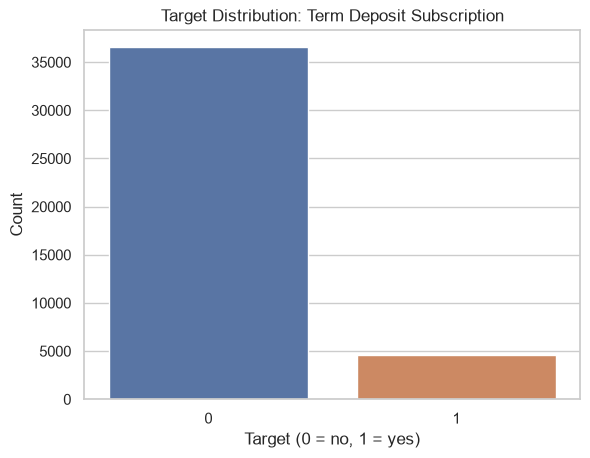

In [143]:
## Target imbalance
ax = sns.countplot(data=df, x="y", palette="deep")
ax.set_title("Target Distribution: Term Deposit Subscription")
ax.set_xlabel("Target (0 = no, 1 = yes)")
ax.set_ylabel("Count")
plt.show()

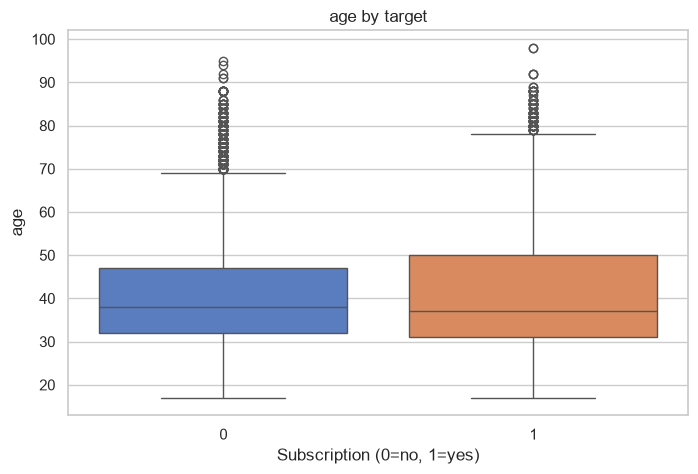

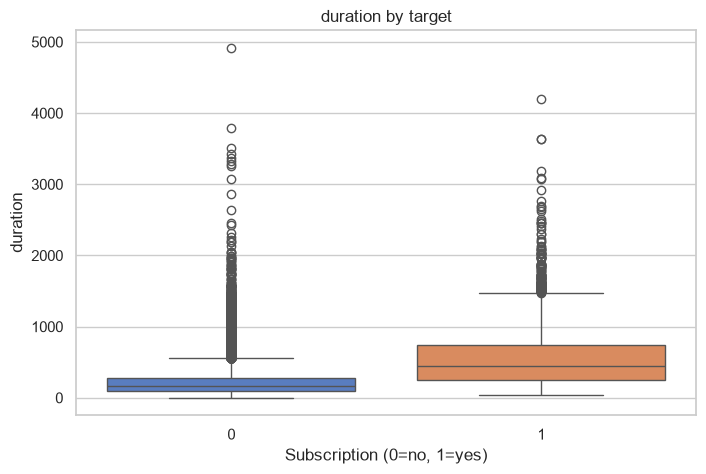

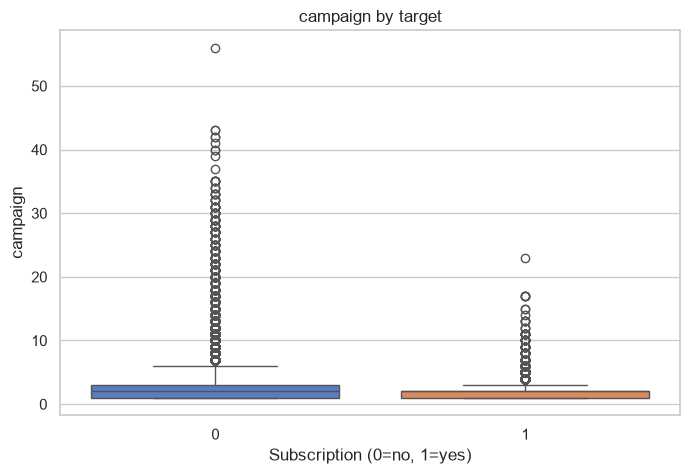

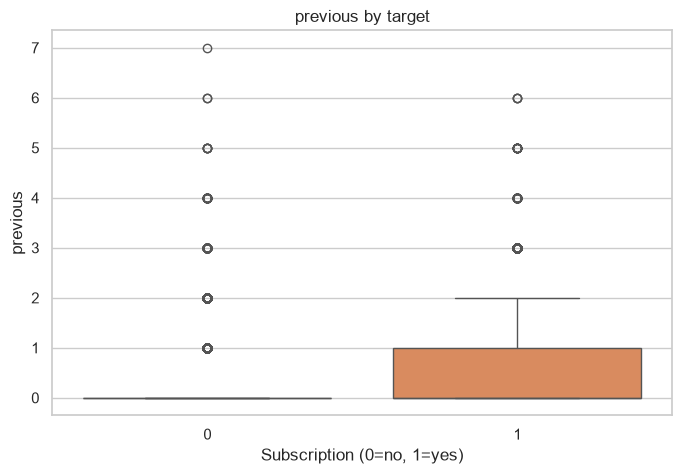

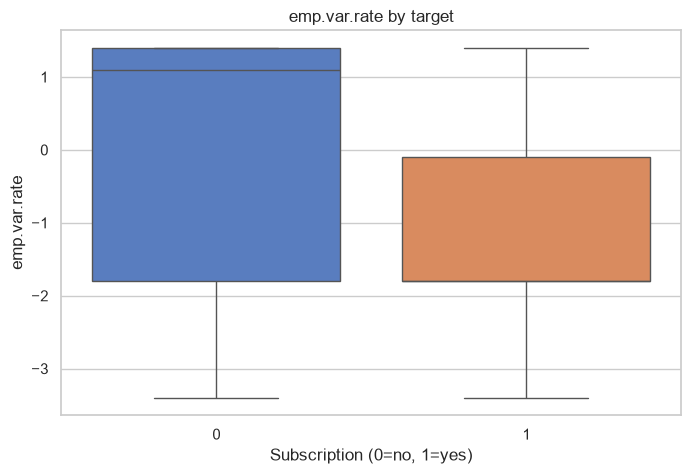

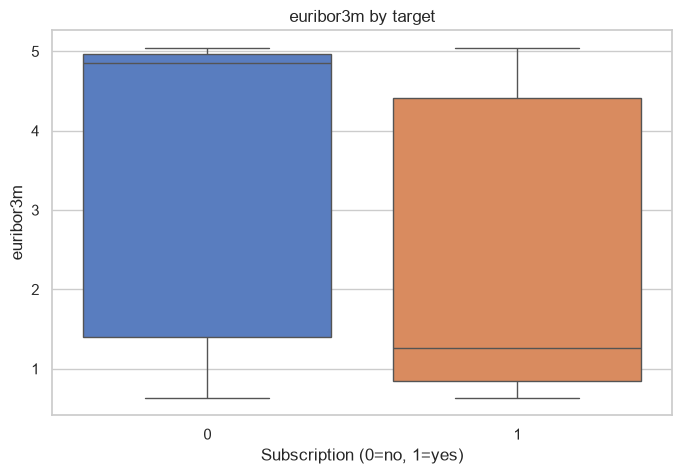

In [144]:
## Key numeric distributions by target
for col in ["age", "duration", "campaign", "previous", "emp.var.rate", "euribor3m"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="y", y=col, palette="muted")
    plt.title(f"{col} by target")
    plt.xlabel("Subscription (0=no, 1=yes)")
    plt.ylabel(col)
    plt.show()


In [145]:
## Categorical signal by target
for col in ["job", "month", "contact", "poutcome"]:
    print(f"\n{col} - positive rate:")
    print((df.groupby(col)["y"].mean() * 100).sort_values(ascending=False).round(2).to_string())



job - positive rate:
job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89

month - positive rate:
month
mar    50.55
dec    48.90
sep    44.91
oct    43.87
apr    20.48
aug    10.60
jun    10.51
nov    10.14
jul     9.05
may     6.43

contact - positive rate:
contact
cellular     14.74
telephone     5.23

poutcome - positive rate:
poutcome
success        65.11
failure        14.23
nonexistent     8.83


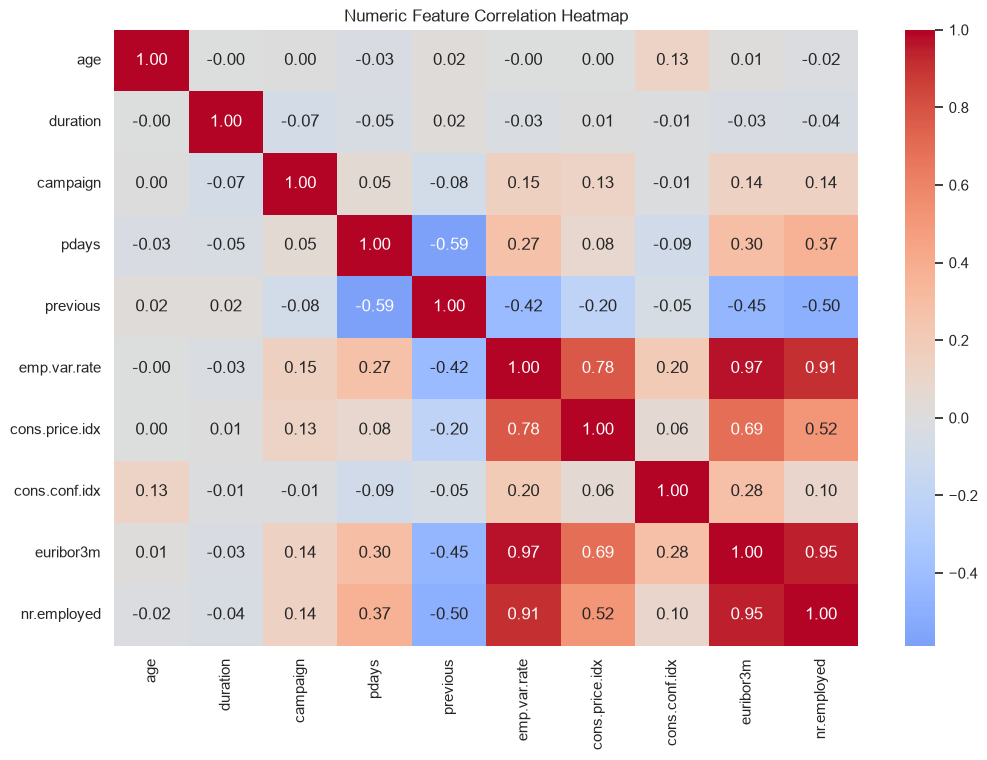

In [146]:
## Correlation heatmap
num_cols = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"
]
plt.figure(figsize=(12, 8))
cor = df[num_cols].corr()
sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()


In [147]:
## No major missing values are expected in this raw file, but we keep our preprocessing robust.
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0].to_string())

df["previously_contacted"] = (df["pdays"] != 999).astype(int)
print("\npreviously_contacted distribution:")
print(df["previously_contacted"].value_counts().to_string())
print("\nPositive rate by previously_contacted:")
print(df.groupby("previously_contacted")["y"].mean().to_string())


Missing values per column:
Series([], )

previously_contacted distribution:
previously_contacted
0    39673
1     1515

Positive rate by previously_contacted:
previously_contacted
0    0.092582
1    0.638284


In [148]:
## Benchmark and production datasets for the leakage analysis.
benchmark_df = df.copy()
production_df = df.drop(columns=["duration"]).copy()
print(f"\nBenchmark rows/cols: {benchmark_df.shape}")
print(f"Production rows/cols: {production_df.shape}")



Benchmark rows/cols: (41188, 22)
Production rows/cols: (41188, 21)


In [149]:
# Create feature sets that align with the business requirement.
# The production model excludes `duration`, while the benchmark keeps it.
benchmark_X = benchmark_df.drop(columns=["y"]).copy()
production_X = production_df.drop(columns=["y"]).copy()
benchmark_y = benchmark_df["y"].copy()
production_y = production_df["y"].copy()

In [150]:
print("Benchmark feature columns:")
print(list(benchmark_X.columns))
print("\nProduction feature columns:")
print(list(production_X.columns))

Benchmark feature columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']

Production feature columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']


In [151]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    benchmark_X,
    benchmark_y,
    test_size=0.20,
    stratify=benchmark_y,
    random_state=RANDOM_STATE,
)


In [152]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    production_X,
    production_y,
    test_size=0.20,
    stratify=production_y,
    random_state=RANDOM_STATE,
)


In [153]:
print(f"\nBenchmark train shape: {X_train_b.shape}, test shape: {X_test_b.shape}")
print(f"Production train shape: {X_train_p.shape}, test shape: {X_test_p.shape}")
print(f"Benchmark target rate: train={y_train_b.mean():.3f}, test={y_test_b.mean():.3f}")
print(f"Production target rate: train={y_train_p.mean():.3f}, test={y_test_p.mean():.3f}")


Benchmark train shape: (32950, 21), test shape: (8238, 21)
Production train shape: (32950, 20), test shape: (8238, 20)
Benchmark target rate: train=0.113, test=0.113
Production target rate: train=0.113, test=0.113


In [154]:
numeric_features = [
    "age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "euribor3m", "nr.employed", "previously_contacted"
]
categorical_features = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"
]

In [155]:
benchmark_numeric = numeric_features + ["duration"]
production_numeric = numeric_features

In [156]:
preprocessor_benchmark = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), benchmark_numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
], remainder="drop")

preprocessor_production = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), production_numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
], remainder="drop")

In [157]:
print("Benchmark numeric columns:", benchmark_numeric)
print("Production numeric columns:", production_numeric)

Benchmark numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'duration']
Production numeric columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']


In [ ]:
def build_pipeline(model, preprocessor):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

baseline_models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.8,
        scale_pos_weight=(len(df)-df["y"].sum()) / df["y"].sum(),
    ),
}


In [159]:
def evaluate_cv(model_name, estimator, X_train, y_train, preprocessor):
    pipe = build_pipeline(estimator, preprocessor)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    metrics = ["roc_auc", "average_precision", "precision", "recall", "f1"]
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=metrics,
        n_jobs=-1,
    )
    summary = {}
    for metric in metrics:
        summary[metric] = (scores[f"test_{metric}"].mean(), scores[f"test_{metric}"].std())
    print(f"\n=== {model_name} ===")
    for metric, (mean, std) in summary.items():
        print(f"{metric}: mean={mean:.4f}, std={std:.4f}")
    return summary

In [160]:
prod_baseline_results = {}
for name, model in baseline_models.items():
    prod_baseline_results[name] = evaluate_cv(name, model, X_train_p, y_train_p, preprocessor_production)

## Benchmark vs production comparison with logistic regression to quantify the leakage effect.
logit_benchmark = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    preprocessor_benchmark,
)
logit_production = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    preprocessor_production,
)


=== DummyClassifier ===
roc_auc: mean=0.5000, std=0.0000
average_precision: mean=0.1127, std=0.0001
precision: mean=0.0000, std=0.0000
recall: mean=0.0000, std=0.0000
f1: mean=0.0000, std=0.0000

=== LogisticRegression ===
roc_auc: mean=0.7896, std=0.0054
average_precision: mean=0.4438, std=0.0081
precision: mean=0.3510, std=0.0058
recall: mean=0.6228, std=0.0066
f1: mean=0.4489, std=0.0037

=== DecisionTree ===
roc_auc: mean=0.6185, std=0.0105
average_precision: mean=0.1809, std=0.0077
precision: mean=0.3128, std=0.0167
recall: mean=0.3273, std=0.0215
f1: mean=0.3197, std=0.0180

=== RandomForest ===
roc_auc: mean=0.7730, std=0.0076
average_precision: mean=0.3766, std=0.0143
precision: mean=0.4362, std=0.0122
recall: mean=0.4588, std=0.0144
f1: mean=0.4471, std=0.0111

=== XGBoost ===
roc_auc: mean=0.7957, std=0.0045
average_precision: mean=0.4635, std=0.0128
precision: mean=0.3680, std=0.0056
recall: mean=0.6328, std=0.0069
f1: mean=0.4653, std=0.0044


In [161]:
benchmark_cv = cross_validate(
    logit_benchmark,
    X_train_b,
    y_train_b,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=["roc_auc", "average_precision", "precision", "recall", "f1"],
    n_jobs=-1,
)

In [162]:
production_cv = cross_validate(
    logit_production,
    X_train_p,
    y_train_p,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=["roc_auc", "average_precision", "precision", "recall", "f1"],
    n_jobs=-1,
)


In [163]:
print("\nBenchmark vs production (Logistic Regression):")
for metric in ["test_roc_auc", "test_average_precision", "test_precision", "test_recall", "test_f1"]:
    bm = benchmark_cv[metric].mean()
    pr = production_cv[metric].mean()
    print(f"{metric}: benchmark={bm:.4f}, production={pr:.4f}, delta={pr - bm:.4f}")



Benchmark vs production (Logistic Regression):
test_roc_auc: benchmark=0.9355, production=0.7896, delta=-0.1459
test_average_precision: benchmark=0.5809, production=0.4438, delta=-0.1371
test_precision: benchmark=0.4354, production=0.3510, delta=-0.0843
test_recall: benchmark=0.8788, production=0.6228, delta=-0.2559
test_f1: benchmark=0.5823, production=0.4489, delta=-0.1333


In [ ]:
xgb_param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2],
    "model__reg_alpha": [0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [1.0, 1.5, 2.0],
    }

In [165]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=(len(df)-df["y"].sum()) / df["y"].sum(),
)


In [166]:
xgb_pipeline = build_pipeline(xgb_model, preprocessor_production)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=12,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

In [167]:
xgb_search.fit(X_train_p, y_train_p)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using `

In [168]:
print("Best XGBoost parameters:", xgb_search.best_params_)
print("Best CV average_precision:", xgb_search.best_score_)

Best XGBoost parameters: {'model__subsample': 0.7, 'model__reg_lambda': 2.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 600, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0, 'model__colsample_bytree': 0.7}
Best CV average_precision: 0.4674968769622129


In [169]:
best_xgb = xgb_search.best_estimator_

logit_pipeline = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    preprocessor_production,
)
logit_search = RandomizedSearchCV(
    estimator=logit_pipeline,
    param_distributions={"model__C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    n_iter=7,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

In [170]:
logit_search.fit(X_train_p, y_train_p)
print("Best Logistic Regression C:", logit_search.best_params_)
print("Best LR CV average_precision:", logit_search.best_score_)

Best Logistic Regression C: {'model__C': 5.0}
Best LR CV average_precision: 0.4438565396525411


In [171]:
best_logit = logit_search.best_estimator_

In [172]:
final_candidates = {
    "DummyClassifier": build_pipeline(DummyClassifier(strategy="most_frequent"), preprocessor_production),
    "LogisticRegression": build_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        preprocessor_production,
    ),
    "DecisionTree": build_pipeline(
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        preprocessor_production,
    ),
    "RandomForest": build_pipeline(
        RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1),
        preprocessor_production,
    ),
    "XGBoost": best_xgb,
    "TunedLogistic": best_logit,
}

In [173]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison_rows = []
for name, model in final_candidates.items():
    scores = cross_validate(
        model,
        X_train_p,
        y_train_p,
        cv=cv,
        scoring=["roc_auc", "average_precision", "precision", "recall", "f1"],
        n_jobs=-1,
    )
    comparison_rows.append({
        "Model": name,
        "ROC-AUC mean": scores["test_roc_auc"].mean(),
        "ROC-AUC std": scores["test_roc_auc"].std(),
        "PR-AUC mean": scores["test_average_precision"].mean(),
        "PR-AUC std": scores["test_average_precision"].std(),
        "Precision mean": scores["test_precision"].mean(),
        "Recall mean": scores["test_recall"].mean(),
        "F1 mean": scores["test_f1"].mean(),
    })


In [174]:
model_comparison = pd.DataFrame(comparison_rows).sort_values("PR-AUC mean", ascending=False)
print(model_comparison.round(4).to_string(index=False))

             Model  ROC-AUC mean  ROC-AUC std  PR-AUC mean  PR-AUC std  Precision mean  Recall mean  F1 mean
           XGBoost        0.7975       0.0039       0.4675      0.0124          0.3632       0.6323   0.4613
     TunedLogistic        0.7896       0.0055       0.4439      0.0083          0.3513       0.6226   0.4491
LogisticRegression        0.7896       0.0054       0.4438      0.0081          0.3510       0.6228   0.4489
      RandomForest        0.7730       0.0076       0.3766      0.0143          0.4362       0.4588   0.4471
      DecisionTree        0.6185       0.0105       0.1809      0.0077          0.3128       0.3273   0.3197
   DummyClassifier        0.5000       0.0000       0.1127      0.0001          0.0000       0.0000   0.0000


In [175]:
final_model_name = model_comparison.iloc[0]["Model"]
final_model = final_candidates[final_model_name]
print(f"\nSelected production model: {final_model_name}")


Selected production model: XGBoost


In [176]:
final_model.fit(X_train_p, y_train_p)
final_proba = final_model.predict_proba(X_test_p)[:, 1]
final_pred = (final_proba >= 0.5).astype(int)

In [177]:
print(f"Final model selected: {final_model_name}")
print(f"Average predicted probability: {final_proba.mean():.3f}")
print(f"Prediction range: [{final_proba.min():.3f}, {final_proba.max():.3f}]")

Final model selected: XGBoost
Average predicted probability: 0.383
Prediction range: [0.074, 0.970]


In [178]:
def report_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nConfusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["no", "yes"], digits=4))
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "roc_auc": roc_auc, "pr_auc": pr_auc}


Production model test metrics (threshold = 0.5):
Accuracy: 0.8404
Precision: 0.3796
Recall: 0.6573
F1: 0.4813
ROC-AUC: 0.8154
PR-AUC: 0.4853

Confusion matrix:
[[6313  997]
 [ 318  610]]

Classification report:
              precision    recall  f1-score   support

          no     0.9520    0.8636    0.9057      7310
         yes     0.3796    0.6573    0.4813       928

    accuracy                         0.8404      8238
   macro avg     0.6658    0.7605    0.6935      8238
weighted avg     0.8876    0.8404    0.8579      8238



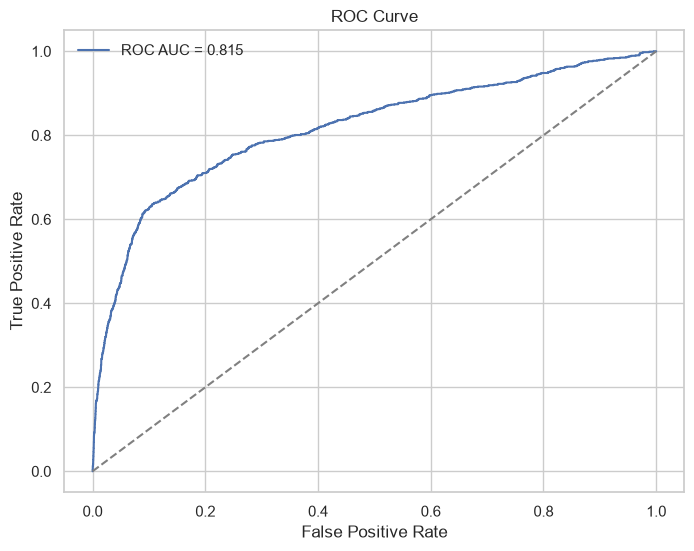

In [179]:
print("\nProduction model test metrics (threshold = 0.5):")
final_test_metrics = report_metrics(y_test_p, final_pred, final_proba)

fpr, tpr, _ = roc_curve(y_test_p, final_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_p, final_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {final_test_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

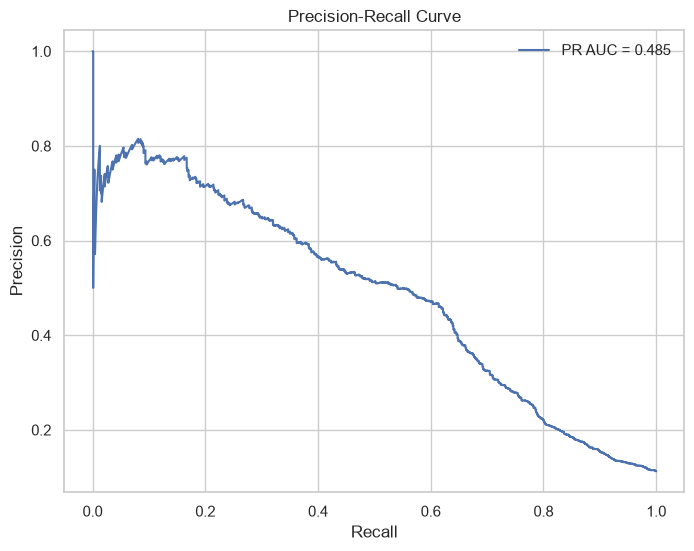

In [180]:
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {final_test_metrics['pr_auc']:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


In [181]:
## Calibration quality assessment for the selected model.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(final_proba, y_test_p)
calibrated_proba = calibrator.predict(final_proba)

print(f"Brier score (raw): {brier_score_loss(y_test_p, final_proba):.4f}")
print(f"Brier score (calibrated): {brier_score_loss(y_test_p, calibrated_proba):.4f}")


Brier score (raw): 0.1539
Brier score (calibrated): 0.0737


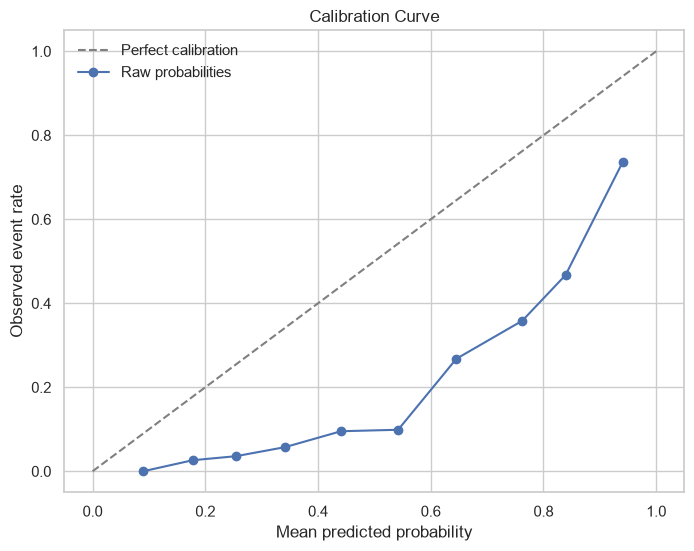

In [182]:
## Calibration curve
raw_mean = []
obs_mean = []
for i in range(10):
    lo = i / 10
    hi = (i + 1) / 10
    mask = (final_proba >= lo) & (final_proba < hi if i < 9 else final_proba <= hi)
    if mask.any():
        raw_mean.append(final_proba[mask].mean())
        obs_mean.append(y_test_p[mask].mean())

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(raw_mean, obs_mean, marker="o", label="Raw probabilities")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed event rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()


In [183]:
thresholds = np.linspace(0.10, 0.90, 17)
threshold_summary = []
for thr in thresholds:
    pred = (final_proba >= thr).astype(int)
    precision = precision_score(y_test_p, pred, zero_division=0)
    recall = recall_score(y_test_p, pred, zero_division=0)
    f1 = f1_score(y_test_p, pred, zero_division=0)
    selected = pred.sum()
    threshold_summary.append({
        "threshold": thr,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "selected": int(selected),
        "pct_selected": selected / len(pred),
    })

threshold_df = pd.DataFrame(threshold_summary)
print(threshold_df.round(4).to_string(index=False))


 threshold  precision  recall     f1  selected  pct_selected
      0.10     0.1129  1.0000 0.2029      8221        0.9979
      0.15     0.1137  0.9989 0.2042      8151        0.9894
      0.20     0.1242  0.9731 0.2202      7272        0.8827
      0.25     0.1381  0.9246 0.2403      6212        0.7541
      0.30     0.1700  0.8772 0.2848      4789        0.5813
      0.35     0.2351  0.7888 0.3623      3113        0.3779
      0.40     0.3065  0.7144 0.4290      2163        0.2626
      0.45     0.3490  0.6821 0.4617      1814        0.2202
      0.50     0.3796  0.6573 0.4813      1607        0.1951
      0.55     0.4254  0.6390 0.5108      1394        0.1692
      0.60     0.4561  0.6207 0.5258      1263        0.1533
      0.65     0.4726  0.5948 0.5267      1168        0.1418
      0.70     0.4849  0.5722 0.5250      1095        0.1329
      0.75     0.5061  0.5356 0.5204       982        0.1192
      0.80     0.5469  0.4332 0.4835       735        0.0892
      0.85     0.6684  0

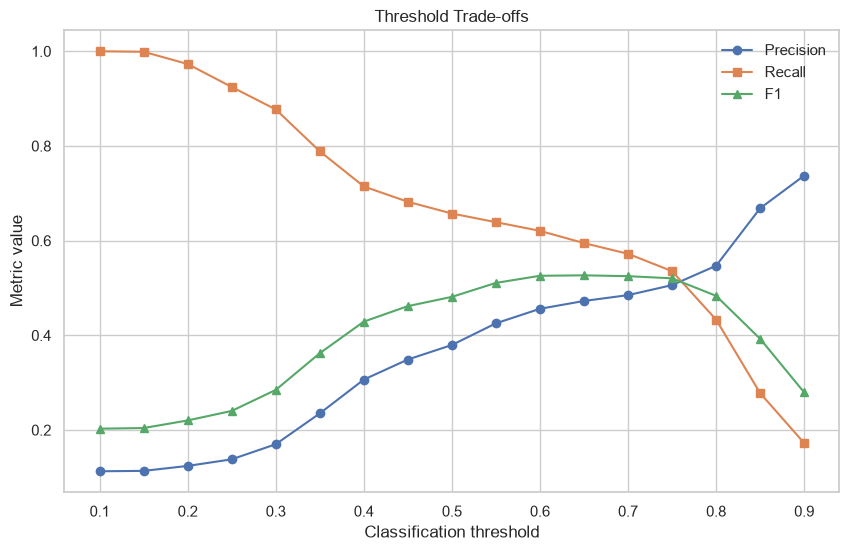

In [184]:

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", marker="o")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", marker="s")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", marker="^")
plt.xlabel("Classification threshold")
plt.ylabel("Metric value")
plt.title("Threshold Trade-offs")
plt.legend()
plt.grid(True)
plt.show()


SHAP method: TreeExplainer


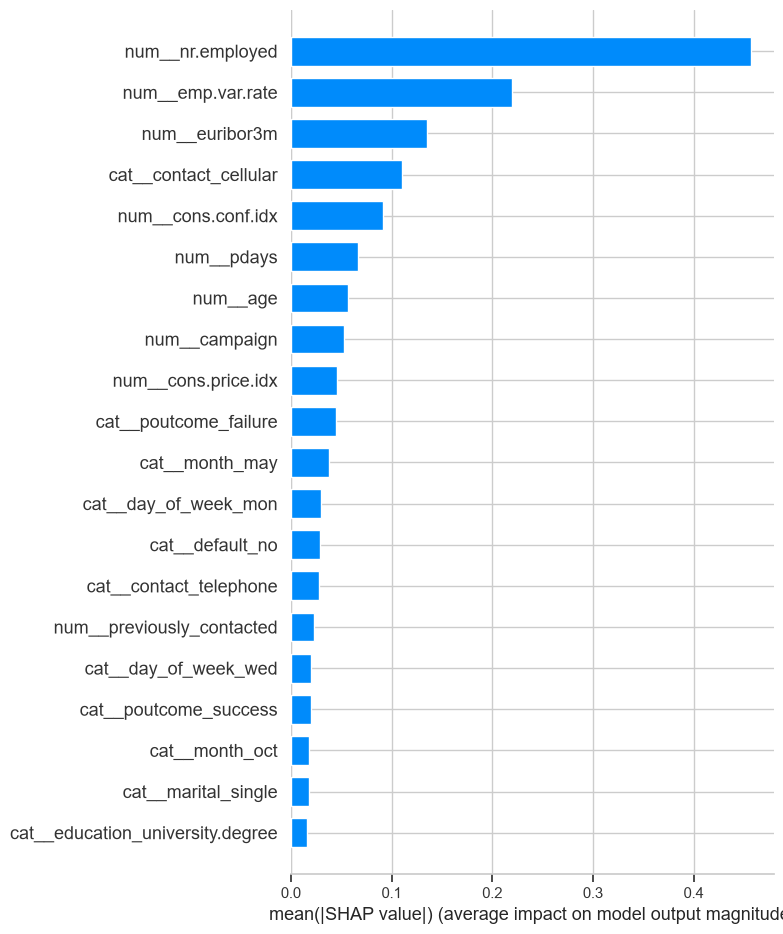

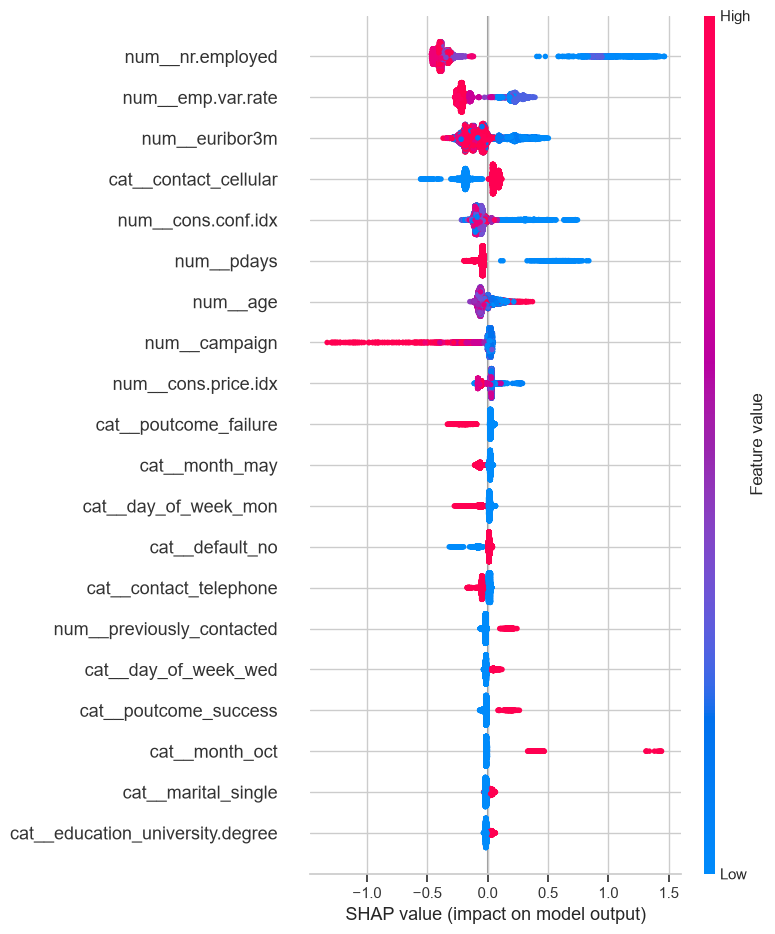


Most positive predicted customer index in test set: 4698
Customer probability: 0.9697
Actual label: 1


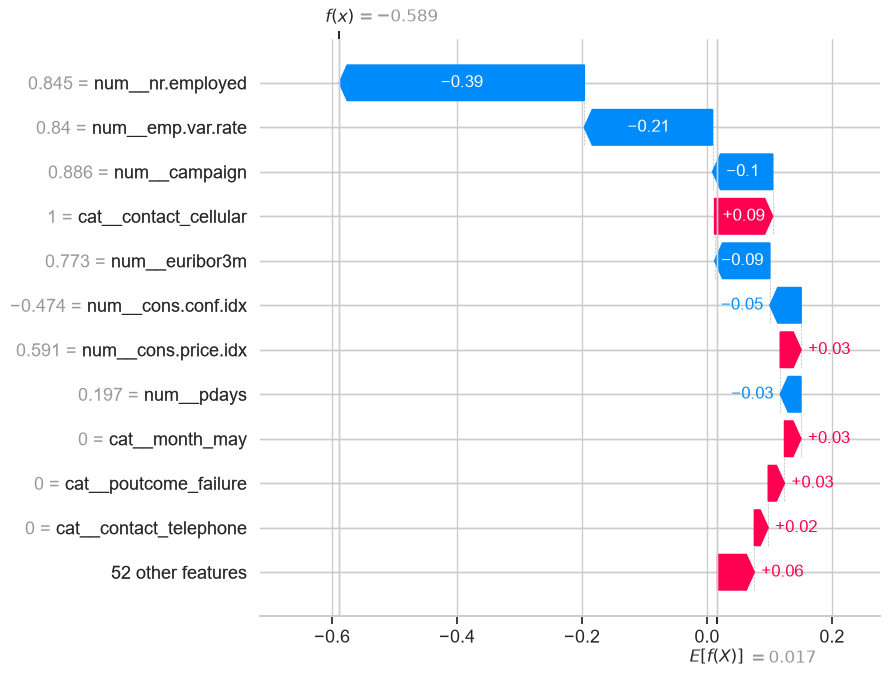

In [185]:
X_train_processed = final_model.named_steps["preprocessor"].fit_transform(X_train_p)
X_test_processed = final_model.named_steps["preprocessor"].transform(X_test_p)
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Use tree SHAP when supported by the installed SHAP/XGBoost versions.
try:
    tree_explainer = shap.TreeExplainer(
        final_model.named_steps["model"],
        feature_perturbation="tree_path_dependent",
    )
    raw_shap_values = tree_explainer.shap_values(X_test_processed)
    if isinstance(raw_shap_values, list):
        raw_shap_values = raw_shap_values[1]
    base_value = tree_explainer.expected_value[1] if isinstance(tree_explainer.expected_value, np.ndarray) else tree_explainer.expected_value
    shap_exp = shap.Explanation(
        values=raw_shap_values,
        base_values=base_value,
        data=X_test_processed,
        feature_names=feature_names,
    )
    print("SHAP method: TreeExplainer")
except (NotImplementedError, ValueError, TypeError) as exc:
    # Some SHAP/XGBoost combinations reject categorical metadata even after one-hot encoding.
    print(f"TreeExplainer unavailable ({type(exc).__name__}); using permutation SHAP fallback.")
    background = X_train_processed[:100]
    explain_rows = X_test_processed[:100]
    permutation_explainer = shap.Explainer(
        lambda values: final_model.predict_proba(values)[:, 1],
        background,
        algorithm="permutation",
        feature_names=feature_names,
    )
    shap_exp = permutation_explainer(explain_rows, max_evals=2 * X_test_processed.shape[1] + 1)

shap.summary_plot(shap_exp, plot_type="bar")
shap.summary_plot(shap_exp)

idx = int(np.argmax(final_proba))
print(f"\nMost positive predicted customer index in test set: {idx}")
print(f"Customer probability: {final_proba[idx]:.4f}")
print(f"Actual label: {y_test_p.iloc[idx]}")
shap.plots.waterfall(shap_exp[0], max_display=12)

# SHAP explanations are descriptive of model behavior and not causal proof.


In [186]:
example_customer = pd.DataFrame([
    {
        "age": 42,
        "job": "management",
        "marital": "married",
        "education": "university.degree",
        "default": "no",
        "housing": "yes",
        "loan": "no",
        "contact": "cellular",
        "month": "may",
        "day_of_week": "thu",
        "campaign": 2,
        "pdays": 999,
        "previous": 0,
        "poutcome": "nonexistent",
        "emp.var.rate": 1.1,
        "cons.price.idx": 93.994,
        "cons.conf.idx": -36.4,
        "euribor3m": 4.857,
        "nr.employed": 5191.0,
        "previously_contacted": 0,
    }
])

# Reorder columns to match the training feature schema.
example_customer = example_customer[production_X.columns]
example_probability = final_model.predict_proba(example_customer)[0, 1]
example_class = "yes" if example_probability >= 0.5 else "no"

print(f"Prediction: {example_class}")
print(f"Subscription probability: {example_probability:.4f}")


Prediction: no
Subscription probability: 0.2380


In [ ]:
print("\nFinal model summary:")
print(f"- Dataset rows: {df.shape[0]}, columns: {df.shape[1]}")
print(f"- Positive rate: {df['y'].mean():.3f}")
print(f"- Production model: {final_model_name}")
print(f"- Final test ROC-AUC: {final_test_metrics['roc_auc']:.4f}")
print(f"- Final test PR-AUC: {final_test_metrics['pr_auc']:.4f}")
print(f"- Final test F1: {final_test_metrics['f1']:.4f}")
print(f"- Example customer prediction: {example_class}, probability={example_probability:.4f}")


Final model summary:
- Dataset rows: 41188, columns: 22
- Positive rate: 0.113
- Production model: XGBoost
- Final test ROC-AUC: 0.8154
- Final test PR-AUC: 0.4853
- Final test F1: 0.4813
- Example customer prediction: no, probability=0.2380


In [189]:
import pickle

MODEL_DIR = Path(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\Customer_Analytics")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "bank_marketing_propensity_model.pkl"

with MODEL_PATH.open("wb") as model_file:
    pickle.dump(final_model, model_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved final model to: {MODEL_PATH}")
print(f"File size: {MODEL_PATH.stat().st_size:,} bytes")


Saved final model to: C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\Customer_Analytics\bank_marketing_propensity_model.pkl
File size: 986,777 bytes
